In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('bigmart.csv')

# Clean — carried from Project 1
df['FatContent'] = df['FatContent'].replace({
    'low fat': 'Low Fat',
    'LF'     : 'Low Fat',
    'reg'    : 'Regular'
})
df['Weight'] = df.groupby('ProductType')['Weight'].transform(
    lambda x: x.fillna(x.median())
)
df['OutletSize'] = df.groupby('OutletType')['OutletSize'].transform(
    lambda x: x.fillna(x.mode()[0])
)
df['OutletAge'] = 2025 - df['EstablishmentYear']

print("Ready ✅")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Ready ✅
Shape: (8523, 13)
Missing values: 0


In [10]:
# Business Questions we will answer in this EDA

questions = """
ABOUT PRODUCTS
──────────────
Q1.  Which product types generate the most sales?
Q2.  Does a higher MRP always mean higher sales?
Q3.  Do low fat products outsell regular fat products?
Q4.  Which products have highest visibility — do they sell more?

ABOUT OUTLETS
─────────────
Q5.  Which outlet type performs best in sales?
Q6.  Do bigger outlets sell more than smaller ones?
Q7.  Does outlet location (Tier 1/2/3) affect sales?
Q8.  Do older outlets perform better than newer ones?

ABOUT THE DATA ITSELF
──────────────────────
Q9.  How is sales data distributed — is it skewed?
Q10. Which columns have the strongest relationship with sales?
Q11. Are there any outliers — which columns have them?
Q12. Which factors influence sales the most?
"""

print(questions)


ABOUT PRODUCTS
──────────────
Q1.  Which product types generate the most sales?
Q2.  Does a higher MRP always mean higher sales?
Q3.  Do low fat products outsell regular fat products?
Q4.  Which products have highest visibility — do they sell more?

ABOUT OUTLETS
─────────────
Q5.  Which outlet type performs best in sales?
Q6.  Do bigger outlets sell more than smaller ones?
Q7.  Does outlet location (Tier 1/2/3) affect sales?
Q8.  Do older outlets perform better than newer ones?

ABOUT THE DATA ITSELF
──────────────────────
Q9.  How is sales data distributed — is it skewed?
Q10. Which columns have the strongest relationship with sales?
Q11. Are there any outliers — which columns have them?
Q12. Which factors influence sales the most?



In [11]:
# Univariate Analysis — Numeric Columns
# Lesson 1 / Part A — Statistical Summary

numeric_cols = ['Weight', 'MRP', 'ProductVisibility', 'OutletAge', 'OutletSales']

df[numeric_cols].describe().round(2)

,Weight,MRP,ProductVisibility,OutletAge,OutletSales
count,8523.00,8523.00,8523.00,8523.00,8523.00
mean,12.81,140.99,0.07,27.17,2181.29
std,4.24,62.28,0.05,8.37,1706.50
min,4.56,31.29,0.00,16.00,33.29
25%,9.31,93.83,0.03,21.00,834.25
50%,12.85,143.01,0.05,26.00,1794.33
75%,16.00,185.64,0.09,38.00,3101.30
max,21.35,266.89,0.33,40.00,13086.96


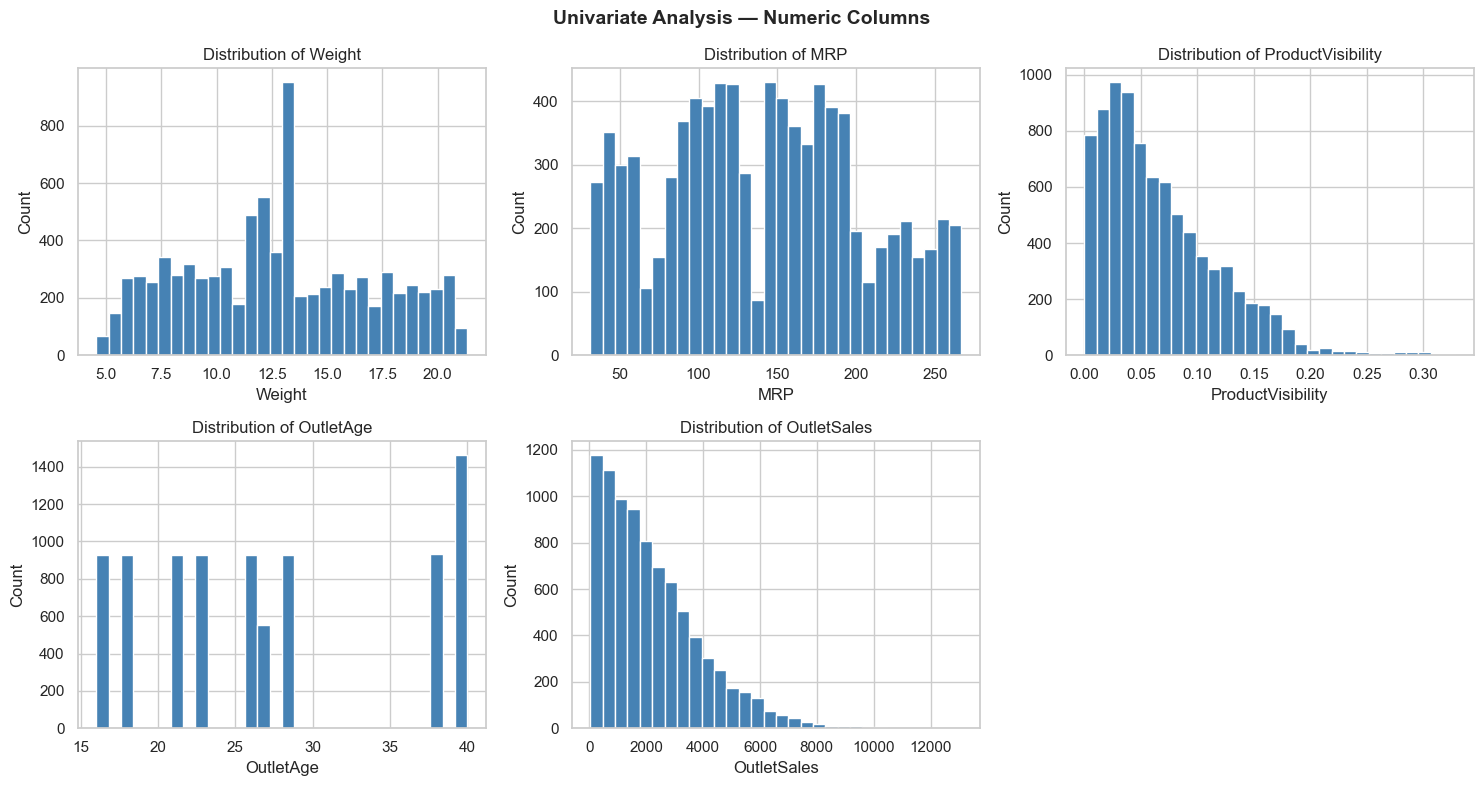

In [12]:
# Univariate Analysis — Numeric Distributions

numeric_cols = ['Weight', 'MRP', 'ProductVisibility', 'OutletAge', 'OutletSales']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

axes[5].set_visible(False)

plt.suptitle('Univariate Analysis — Numeric Columns',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
# Measure skewness of each numeric column

print("=== SKEWNESS ===")
print(df[numeric_cols].skew().round(2))

=== SKEWNESS ===
Weight               0.12
MRP                  0.13
ProductVisibility    1.17
OutletAge            0.40
OutletSales          1.18
dtype: float64


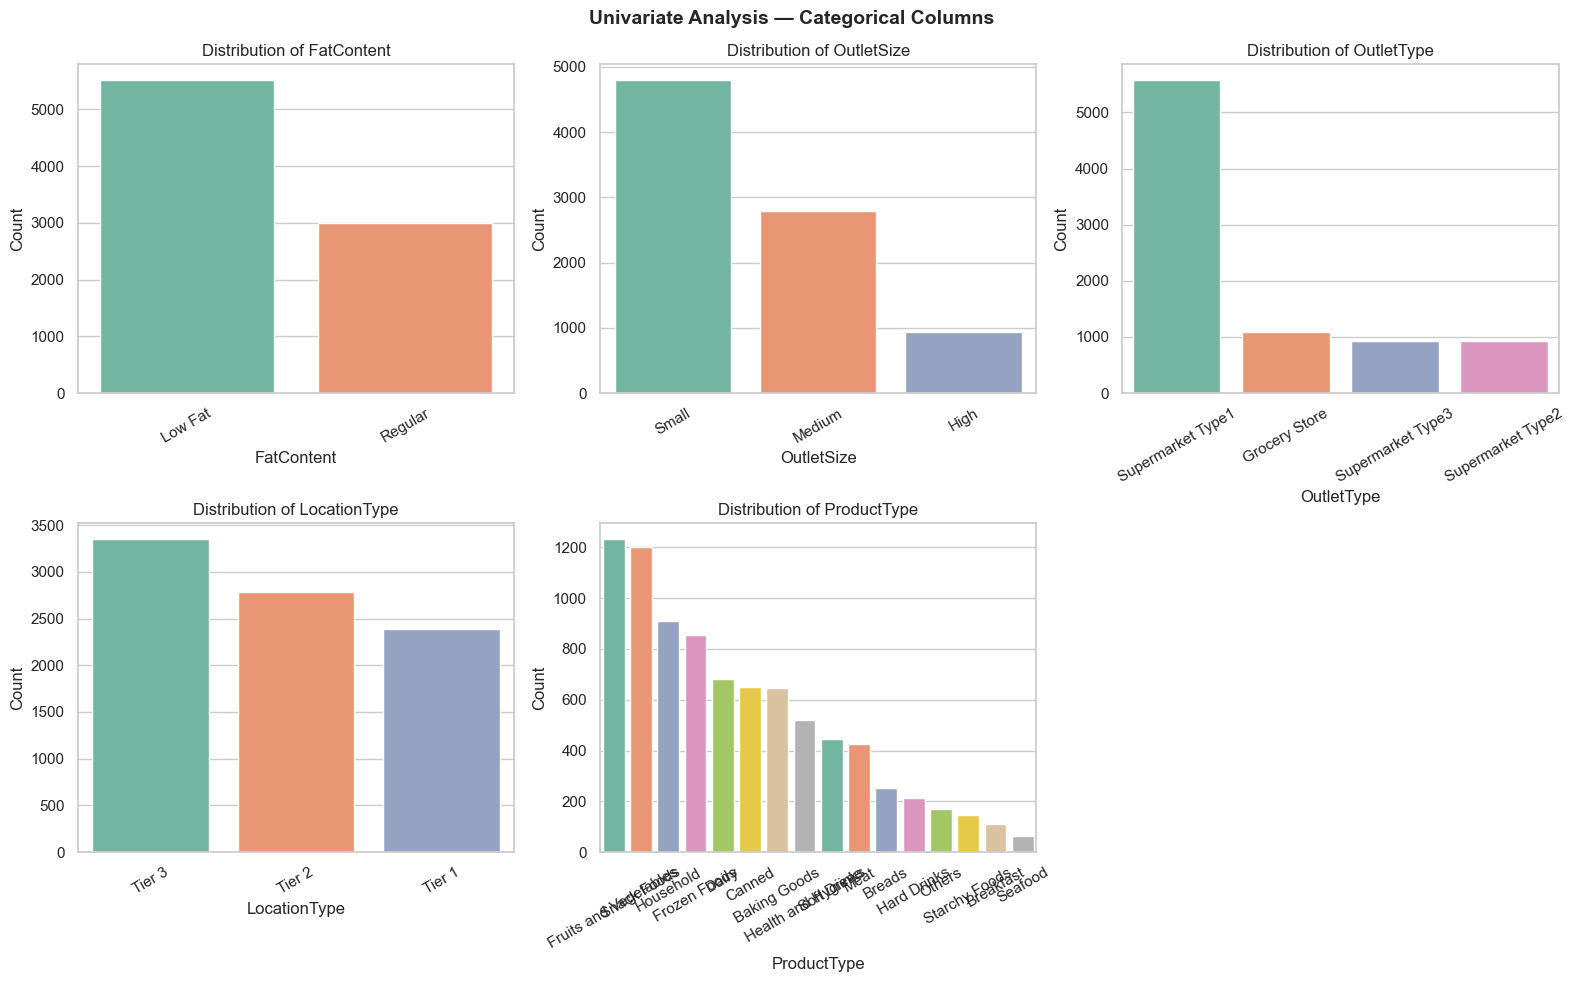

In [14]:
# Univariate Analysis — Categorical Columns

categorical_cols = ['FatContent', 'OutletSize', 'OutletType',
                    'LocationType', 'ProductType']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i],
                  order=order, palette='Set2')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

axes[5].set_visible(False)

plt.suptitle('Univariate Analysis — Categorical Columns',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

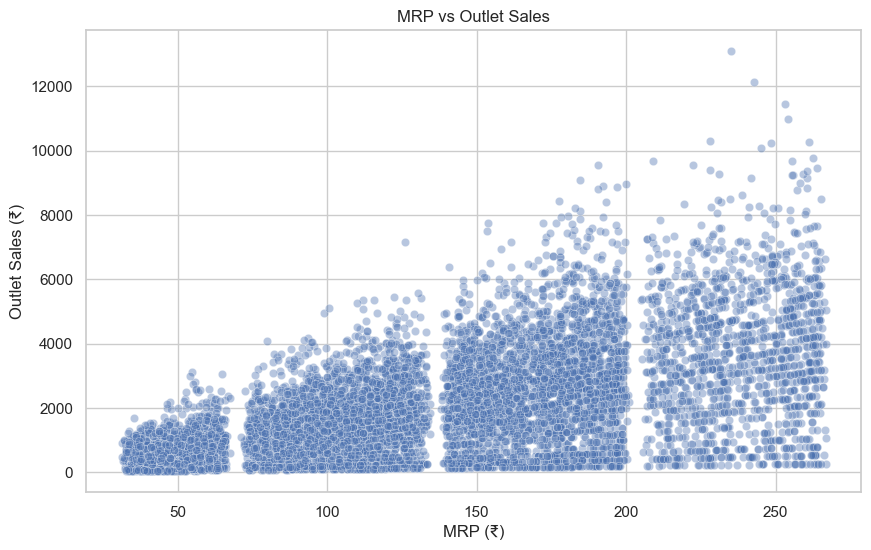

Correlation between MRP and Sales: 0.57


In [15]:
# Bivariate Analysis — Numeric vs Numeric
# Q2. Does higher MRP mean higher sales?

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='MRP', y='OutletSales', alpha=0.4)

plt.title('MRP vs Outlet Sales')
plt.xlabel('MRP (₹)')
plt.ylabel('Outlet Sales (₹)')
plt.show()

correlation = df['MRP'].corr(df['OutletSales'])
print(f"Correlation between MRP and Sales: {correlation:.2f}")

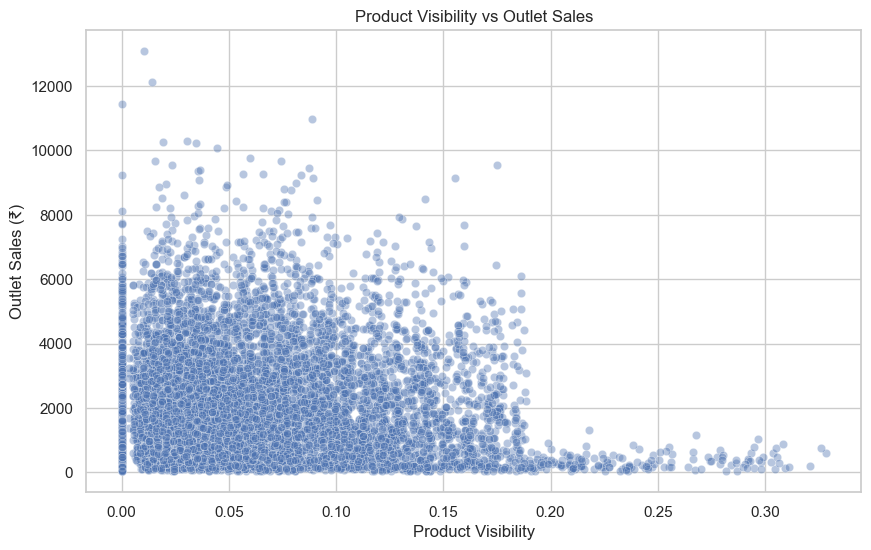

Correlation between Visibility and Sales: -0.13


In [16]:
# Q4. Does higher visibility mean higher sales?

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ProductVisibility', y='OutletSales', alpha=0.4)

plt.title('Product Visibility vs Outlet Sales')
plt.xlabel('Product Visibility')
plt.ylabel('Outlet Sales (₹)')
plt.show()

correlation = df['ProductVisibility'].corr(df['OutletSales'])
print(f"Correlation between Visibility and Sales: {correlation:.2f}")

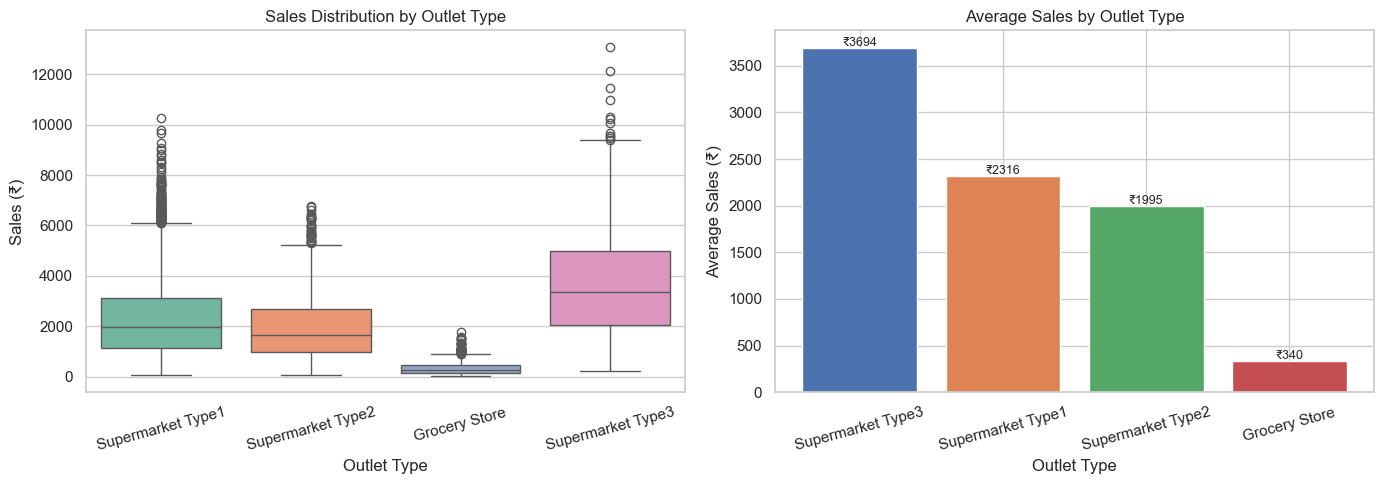

OutletType
Supermarket Type3    3694.04
Supermarket Type1    2316.18
Supermarket Type2    1995.50
Grocery Store         339.83
Name: OutletSales, dtype: float64


In [17]:
# Bivariate Analysis — Categorical vs Numeric
# Q5. Which outlet type performs best in sales?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — full distribution
sns.boxplot(data=df, x='OutletType', y='OutletSales',
            palette='Set2', ax=axes[0])
axes[0].set_title('Sales Distribution by Outlet Type')
axes[0].set_xlabel('Outlet Type')
axes[0].set_ylabel('Sales (₹)')
axes[0].tick_params(axis='x', rotation=15)

# Bar chart — average only
outlet_avg = df.groupby('OutletType')['OutletSales'].mean().sort_values(ascending=False)
axes[1].bar(outlet_avg.index, outlet_avg.values,
            color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white')
axes[1].set_title('Average Sales by Outlet Type')
axes[1].set_xlabel('Outlet Type')
axes[1].set_ylabel('Average Sales (₹)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(outlet_avg.values):
    axes[1].text(i, v + 20, f'₹{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(df.groupby('OutletType')['OutletSales'].mean().sort_values(ascending=False).round(2))

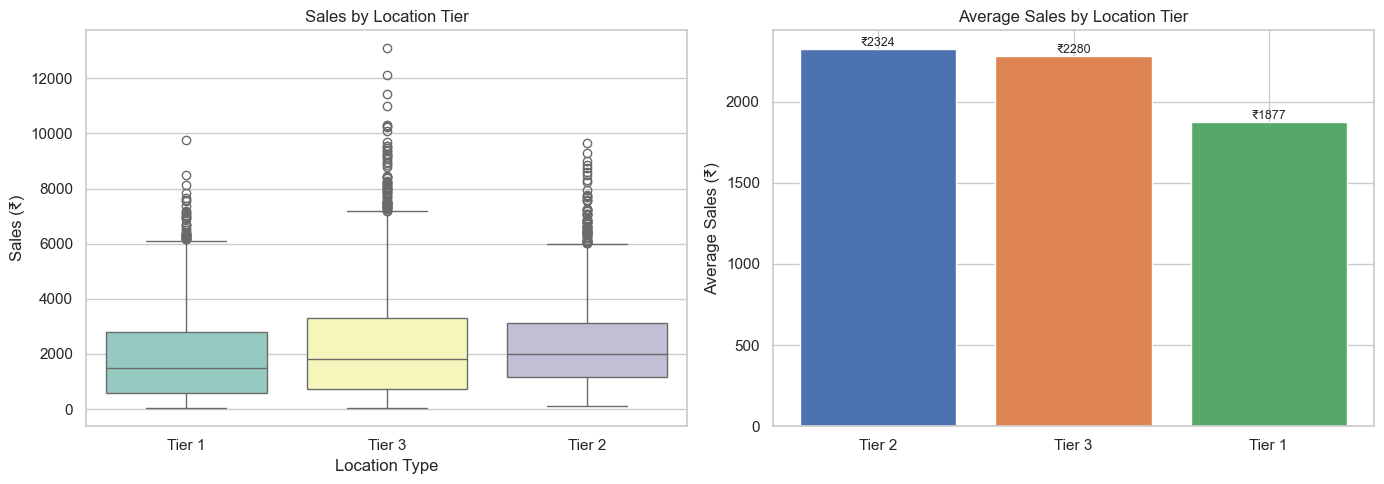

LocationType
Tier 2    2323.99
Tier 3    2279.63
Tier 1    1876.91
Name: OutletSales, dtype: float64


In [18]:
# Q7. Does outlet location affect sales?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='LocationType', y='OutletSales',
            palette='Set3', ax=axes[0])
axes[0].set_title('Sales by Location Tier')
axes[0].set_xlabel('Location Type')
axes[0].set_ylabel('Sales (₹)')

location_avg = df.groupby('LocationType')['OutletSales'].mean().sort_values(ascending=False)
axes[1].bar(location_avg.index, location_avg.values,
            color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
axes[1].set_title('Average Sales by Location Tier')
axes[1].set_ylabel('Average Sales (₹)')
for i, v in enumerate(location_avg.values):
    axes[1].text(i, v + 20, f'₹{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(location_avg.round(2))

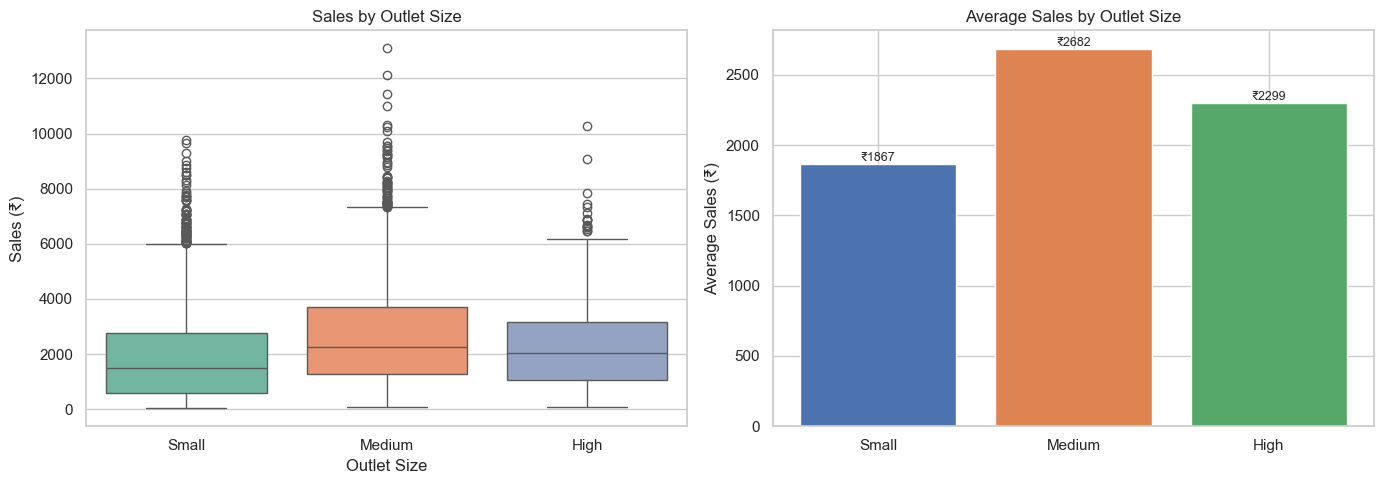

OutletSize
Small     1867.18
Medium    2681.60
High      2299.00
Name: OutletSales, dtype: float64


In [19]:
# Q6. Do bigger outlets sell more?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='OutletSize', y='OutletSales',
            palette='Set2', ax=axes[0],
            order=['Small', 'Medium', 'High'])
axes[0].set_title('Sales by Outlet Size')
axes[0].set_xlabel('Outlet Size')
axes[0].set_ylabel('Sales (₹)')

size_avg = df.groupby('OutletSize')['OutletSales'].mean()
size_avg = size_avg.reindex(['Small', 'Medium', 'High'])
axes[1].bar(size_avg.index, size_avg.values,
            color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
axes[1].set_title('Average Sales by Outlet Size')
axes[1].set_ylabel('Average Sales (₹)')
for i, v in enumerate(size_avg.values):
    axes[1].text(i, v + 20, f'₹{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(size_avg.round(2))

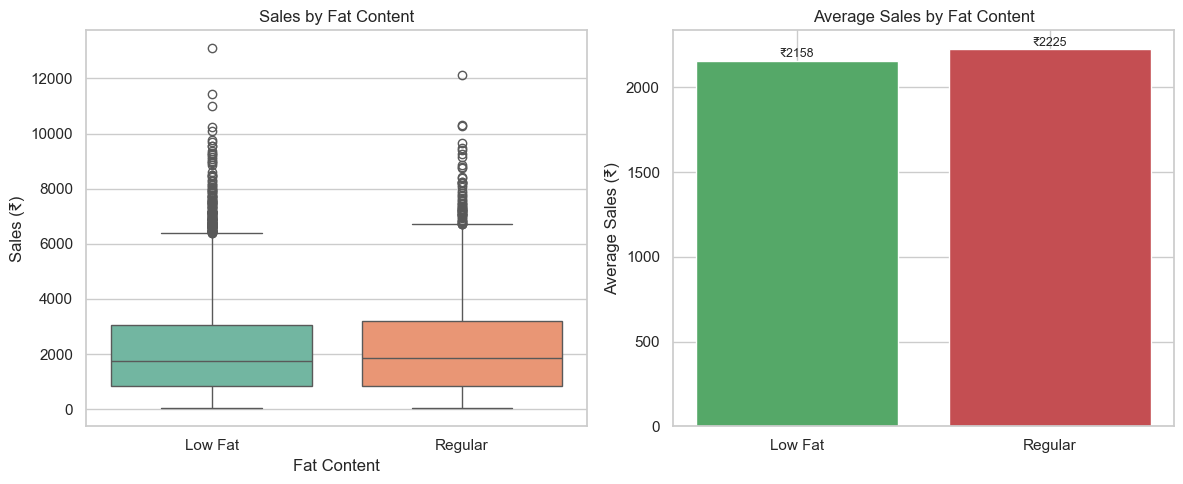

FatContent
Low Fat    2157.71
Regular    2224.56
Name: OutletSales, dtype: float64


In [20]:
# Q3. Do Low Fat products outsell Regular products?

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='FatContent', y='OutletSales',
            palette='Set2', ax=axes[0])
axes[0].set_title('Sales by Fat Content')
axes[0].set_xlabel('Fat Content')
axes[0].set_ylabel('Sales (₹)')

fat_avg = df.groupby('FatContent')['OutletSales'].mean()
axes[1].bar(fat_avg.index, fat_avg.values,
            color=['#55A868','#C44E52'], edgecolor='white')
axes[1].set_title('Average Sales by Fat Content')
axes[1].set_ylabel('Average Sales (₹)')
for i, v in enumerate(fat_avg.values):
    axes[1].text(i, v + 20, f'₹{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(fat_avg.round(2))

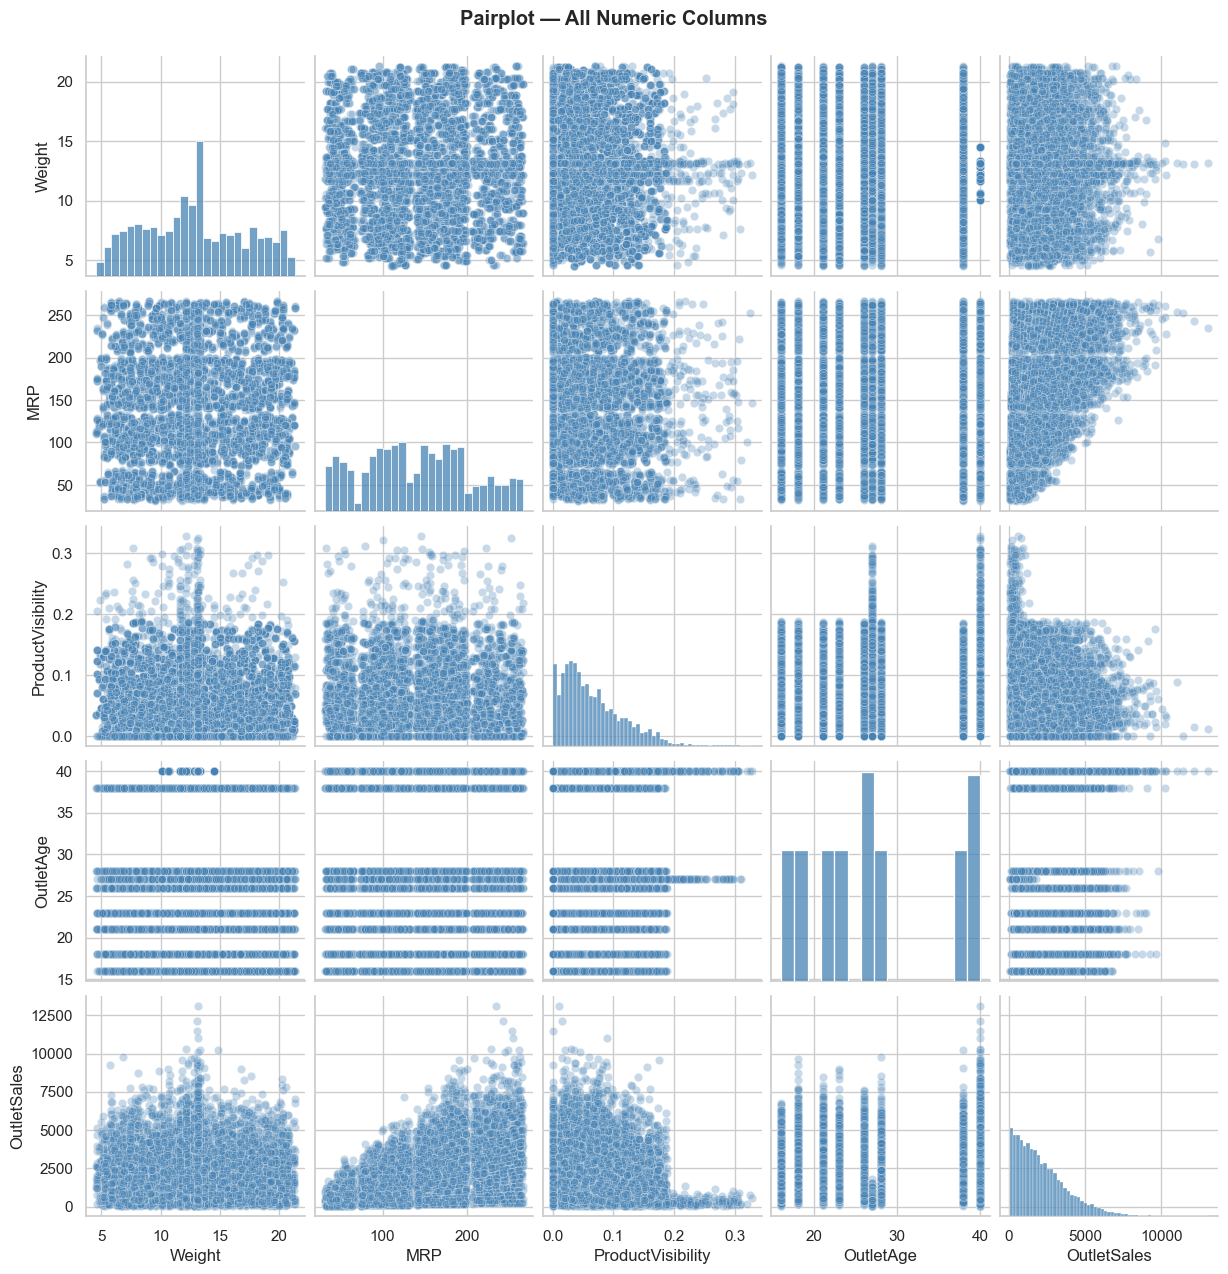

In [21]:
# Multivariate Analysis — Pairplot
# All numeric columns at once

numeric_cols = ['Weight', 'MRP', 'ProductVisibility',
                'OutletAge', 'OutletSales']

sns.pairplot(df[numeric_cols],
             diag_kind='hist',
             plot_kws={'alpha': 0.3, 'color': 'steelblue'},
             diag_kws={'color': 'steelblue', 'edgecolor': 'white'})

plt.suptitle('Pairplot — All Numeric Columns',
             fontweight='bold', y=1.02)
plt.show()

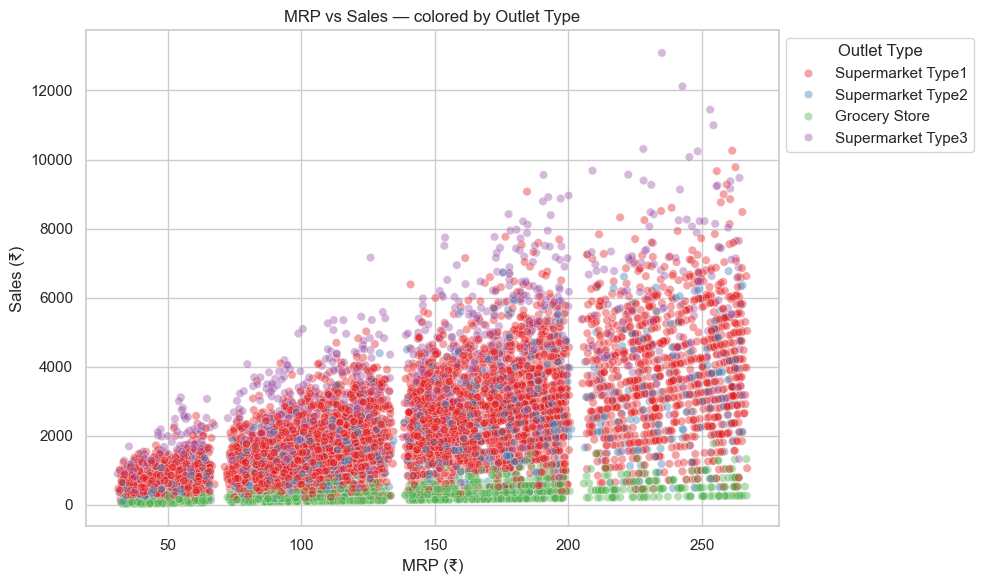

In [25]:
# Multivariate — Color Coded Scatter
# Three variables in one chart
# Does MRP vs Sales relationship change by Outlet Type?

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,
                x='MRP',
                y='OutletSales',
                hue='OutletType',
                alpha=0.4,
                palette='Set1')

plt.title('MRP vs Sales — colored by Outlet Type')
plt.xlabel('MRP (₹)')
plt.ylabel('Sales (₹)')
plt.legend(title='Outlet Type', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

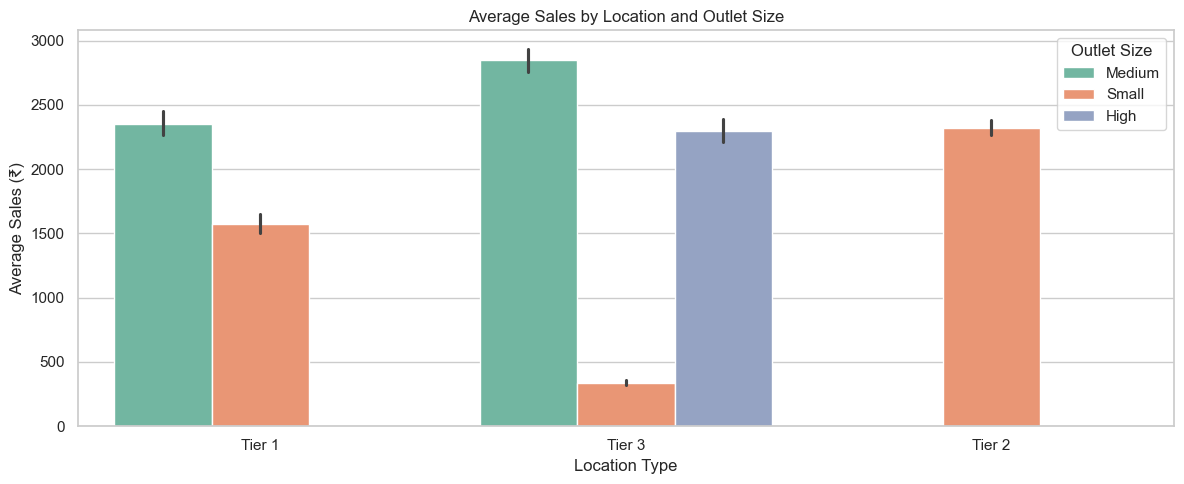

In [26]:
# Multivariate — Grouped Bar Chart
# Location Type + Outlet Size together vs Sales

plt.figure(figsize=(12, 5))
sns.barplot(data=df,
            x='LocationType',
            y='OutletSales',
            hue='OutletSize',
            palette='Set2')

plt.title('Average Sales by Location and Outlet Size')
plt.xlabel('Location Type')
plt.ylabel('Average Sales (₹)')
plt.legend(title='Outlet Size')
plt.tight_layout()
plt.show()

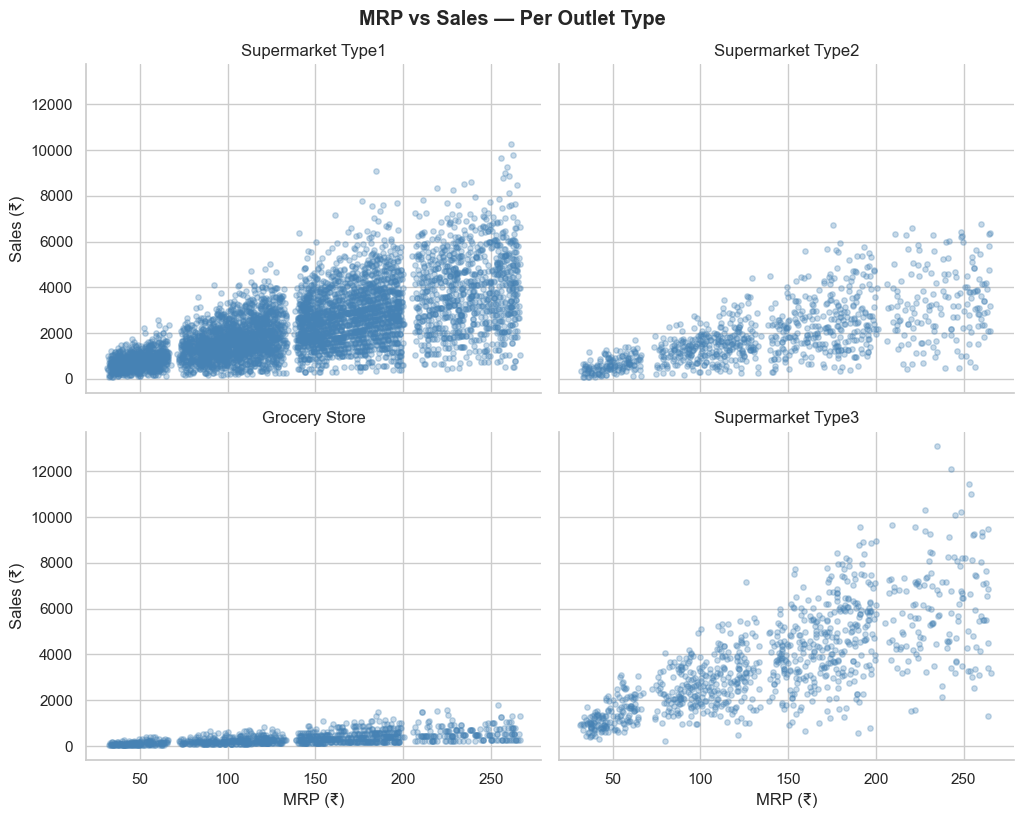

In [27]:
# Multivariate — FacetGrid
# Same chart drawn separately per outlet type

g = sns.FacetGrid(df, col='OutletType',
                  col_wrap=2,
                  height=4, aspect=1.3)

g.map(plt.scatter, 'MRP', 'OutletSales',
      alpha=0.3, color='steelblue', s=15)

g.set_axis_labels('MRP (₹)', 'Sales (₹)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('MRP vs Sales — Per Outlet Type',
                  fontweight='bold', y=1.02)
plt.show()

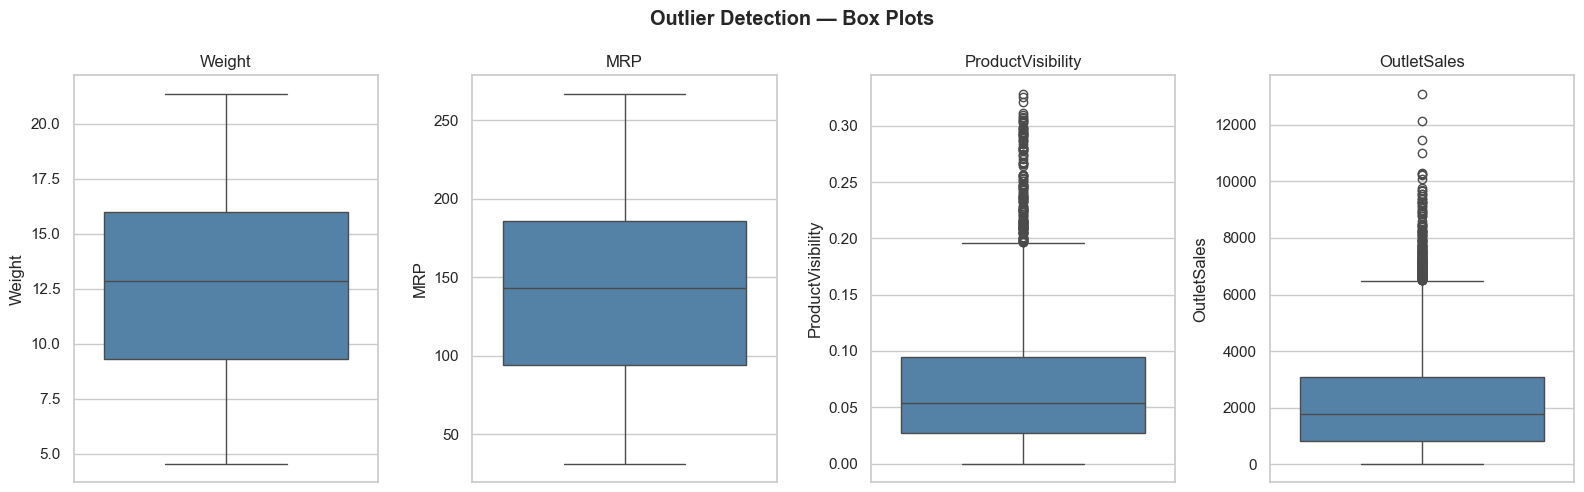

In [28]:
# Outlier Analysis — Visual Detection

numeric_cols = ['Weight', 'MRP', 'ProductVisibility', 'OutletSales']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.suptitle('Outlier Detection — Box Plots',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Outlier Analysis — IQR Method

def find_outliers(col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print(f"  Q1           : {Q1:.2f}")
    print(f"  Q3           : {Q3:.2f}")
    print(f"  IQR          : {IQR:.2f}")
    print(f"  Lower bound  : {lower:.2f}")
    print(f"  Upper bound  : {upper:.2f}")
    print(f"  Outliers     : {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")

for col in ['Weight', 'MRP', 'ProductVisibility', 'OutletSales']:
    find_outliers(col)


Weight
  Q1           : 9.31
  Q3           : 16.00
  IQR          : 6.69
  Lower bound  : -0.72
  Upper bound  : 26.04
  Outliers     : 0 rows (0.0%)

MRP
  Q1           : 93.83
  Q3           : 185.64
  IQR          : 91.82
  Lower bound  : -43.90
  Upper bound  : 323.37
  Outliers     : 0 rows (0.0%)

ProductVisibility
  Q1           : 0.03
  Q3           : 0.09
  IQR          : 0.07
  Lower bound  : -0.07
  Upper bound  : 0.20
  Outliers     : 144 rows (1.7%)

OutletSales
  Q1           : 834.25
  Q3           : 3101.30
  IQR          : 2267.05
  Lower bound  : -2566.33
  Upper bound  : 6501.87
  Outliers     : 186 rows (2.2%)


In [30]:
# Statistical Summaries — Skewness and Kurtosis

numeric_cols = ['Weight', 'MRP', 'ProductVisibility',
                'OutletAge', 'OutletSales']

summary = pd.DataFrame({
    'Mean'    : df[numeric_cols].mean(),
    'Median'  : df[numeric_cols].median(),
    'Std Dev' : df[numeric_cols].std(),
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurtosis()
}).round(2)

print(summary)

                      Mean   Median  Std Dev  Skewness  Kurtosis
Weight               12.81    12.85     4.24      0.12     -0.89
MRP                 140.99   143.01    62.28      0.13     -0.89
ProductVisibility     0.07     0.05     0.05      1.17      1.68
OutletAge            27.17    26.00     8.37      0.40     -1.21
OutletSales        2181.29  1794.33  1706.50      1.18      1.62


In [31]:
# Percentile Analysis

print("=== OUTLETSALES PERCENTILES ===")
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
print(df['OutletSales'].quantile(percentiles).round(2))

print("\n=== GROUPBY SUMMARY ===")
summary = df.groupby('OutletType')['OutletSales'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
summary.columns = ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max']
print(summary.sort_values('Mean', ascending=False))

=== OUTLETSALES PERCENTILES ===
0.10     343.55
0.25     834.25
0.50    1794.33
0.75    3101.30
0.90    4570.05
0.95    5522.81
0.99    7366.01
Name: OutletSales, dtype: float64

=== GROUPBY SUMMARY ===
                   Count     Mean   Median  Std Dev     Min       Max
OutletType                                                           
Supermarket Type3    935  3694.04  3364.95  2127.76  241.69  13086.96
Supermarket Type1   5577  2316.18  1990.74  1515.97   73.24  10256.65
Supermarket Type2    928  1995.50  1655.18  1375.93   69.24   6768.52
Grocery Store       1083   339.83   257.00   260.85   33.29   1775.69


In [32]:
# Lesson 6 — Statistical Summary Table

print("=== VALUE COUNTS WITH PERCENTAGES ===")
counts = df['OutletType'].value_counts()
pct = df['OutletType'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'Count': counts, 'Percentage': pct}))

=== VALUE COUNTS WITH PERCENTAGES ===
                   Count  Percentage
OutletType                          
Supermarket Type1   5577        65.4
Grocery Store       1083        12.7
Supermarket Type3    935        11.0
Supermarket Type2    928        10.9


In [33]:
# Final EDA Summary

print("""
╔══════════════════════════════════════════════════════════╗
║              EDA SUMMARY — BIGMART SALES                 ║
╠══════════════════════════════════════════════════════════╣
║  UNIVARIATE FINDINGS                                     ║
║  • OutletSales and ProductVisibility highly skewed       ║
║  • Weight and MRP are symmetric and consistent           ║
║  • Supermarket Type1 dominates dataset (most products)   ║
║  • Low Fat products outnumber Regular ones               ║
║                                                          ║
║  BIVARIATE FINDINGS                                      ║
║  • MRP moderate positive correlation (0.57)              ║
║  • Visibility weak negative correlation (-0.13)          ║
║  • Type3 outlets highest sales, Grocery lowest           ║
║  • Location tier has minimal impact on sales             ║
║  • Medium outlets outperform Large ones unexpectedly     ║
║  • Fat content has negligible impact on sales            ║
║                                                          ║
║  MULTIVARIATE FINDINGS                                   ║
║  • Outlet type influences sales more than MRP            ║
║  • MRP effect strongest in Type3, irrelevant in Grocery  ║
║  • Tier2 data incomplete — missing outlet size combos    ║
║  • Medium outlets lead across most location tiers        ║
║                                                          ║
║  OUTLIER FINDINGS                                        ║
║  • Weight and MRP → zero outliers                        ║
║  • ProductVisibility → 144 outliers (1.7%) kept          ║
║  • OutletSales → 186 outliers (2.2%) kept                ║
║                                                          ║
║  BUSINESS RECOMMENDATIONS                               ║
║  • Expand Type3 outlets in Tier2 cities                  ║
║  • Focus on Fruits, Vegetables and Snack Foods           ║
║  • Revisit shelf visibility placement strategy           ║
║  • Medium outlet format is the sweet spot for sales      ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              EDA SUMMARY — BIGMART SALES                 ║
╠══════════════════════════════════════════════════════════╣
║  UNIVARIATE FINDINGS                                     ║
║  • OutletSales and ProductVisibility highly skewed       ║
║  • Weight and MRP are symmetric and consistent           ║
║  • Supermarket Type1 dominates dataset (most products)   ║
║  • Low Fat products outnumber Regular ones               ║
║                                                          ║
║  BIVARIATE FINDINGS                                      ║
║  • MRP moderate positive correlation (0.57)              ║
║  • Visibility weak negative correlation (-0.13)          ║
║  • Type3 outlets highest sales, Grocery lowest           ║
║  • Location tier has minimal impact on sales             ║
║  • Medium outlets outperform Large ones unexpectedly     ║
║  • Fat content has negligible impact on sales            ║
║                      